In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv('dataset_nibong_10062026.csv')
display(df.head())

,id,timestamp,temp,hum,gas_ppm,pm1,pm25,pm10
0,1,2026-05-01 12:17:05,31.0,76.1,5.52,6.18,6.53,6.53
1,2,2026-05-01 12:22:07,31.1,75.9,9.38,6.55,6.93,6.93
2,3,2026-05-01 12:27:09,31.0,76.1,5.66,6.24,6.60,6.60
3,4,2026-05-01 12:32:10,31.1,75.9,5.10,7.28,7.70,7.70
4,5,2026-05-01 12:37:12,31.1,75.7,4.44,6.03,6.38,6.38


In [34]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [35]:
df['timestamp'] = df['timestamp'].dt.round('5min')

In [36]:
df = df.drop_duplicates(subset='timestamp')

In [37]:
df.set_index('timestamp', inplace=True)

In [38]:
df = df.resample('5T').asfreq()

C:\Users\haziq\AppData\Local\Temp\ipykernel_6304\153440959.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample('5T').asfreq()


In [39]:
df.isna().sum()

id         90
temp       90
hum        90
gas_ppm    90
pm1        90
pm25       90
pm10       90
dtype: int64

In [40]:
df = df.interpolate(method='linear').round(2)

In [41]:
df.isna().sum()

id         0
temp       0
hum        0
gas_ppm    0
pm1        0
pm25       0
pm10       0
dtype: int64

drop


In [42]:
df.drop(['id'], axis=1, inplace=True)

In [43]:
df

,temp,hum,gas_ppm,pm1,pm25,pm10
timestamp,,,,,,
2026-05-01 12:15:00,31.0,76.1,5.52,6.18,6.53,6.53
2026-05-01 12:20:00,31.1,75.9,9.38,6.55,6.93,6.93
2026-05-01 12:25:00,31.0,76.1,5.66,6.24,6.60,6.60
2026-05-01 12:30:00,31.1,75.9,5.10,7.28,7.70,7.70
2026-05-01 12:35:00,31.1,75.7,4.44,6.03,6.38,6.38
...,...,...,...,...,...,...
2026-06-10 10:50:00,31.4,69.9,354.69,2.10,2.22,2.22
2026-06-10 10:55:00,31.4,69.8,337.32,2.42,2.56,2.56
2026-06-10 11:00:00,31.5,70.2,362.65,2.10,2.22,2.22


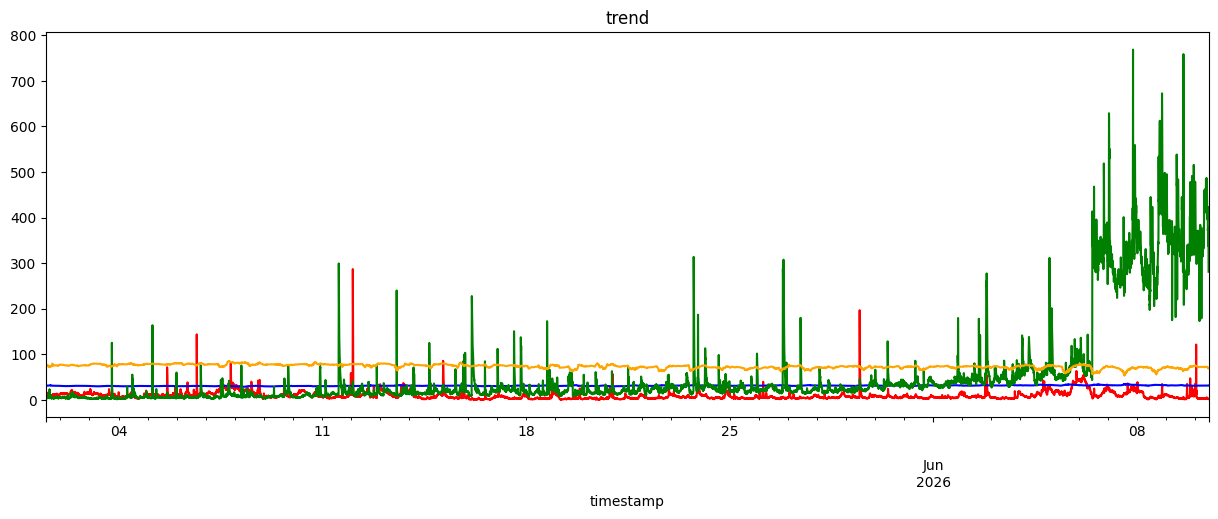

In [44]:
df['pm25'].plot(figsize=(15,5),title='trend', color='red')
df['temp'].plot(figsize=(15,5),title='trend', color='blue')
df['gas_ppm'].plot(figsize=(15,5),title='trend', color='green')
df['hum'].plot(figsize=(15,5),title='trend', color='orange')
plt.show()

In [27]:
#df.to_csv('Clean_dataset_nibong_05062026.csv')

In [45]:
df = df[df['pm25'] <= 100]

In [46]:
df = df[df['gas_ppm'] <= 150]

In [47]:
df.isna().sum()

temp       0
hum        0
gas_ppm    0
pm1        0
pm25       0
pm10       0
dtype: int64

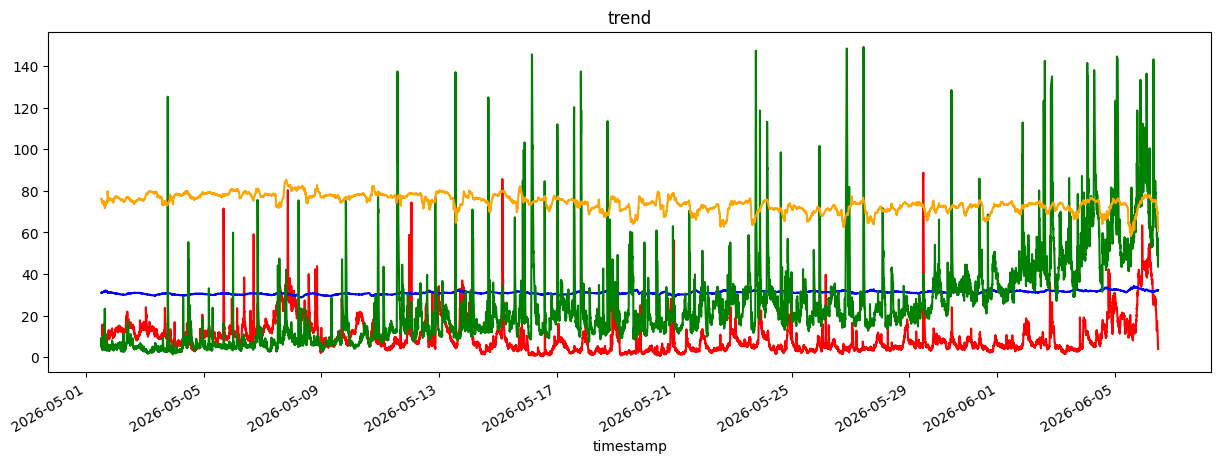

In [48]:
df['pm25'].plot(figsize=(15,5),title='trend', color='red')
df['temp'].plot(figsize=(15,5),title='trend', color='blue')
df['gas_ppm'].plot(figsize=(15,5),title='trend', color='green')
df['hum'].plot(figsize=(15,5),title='trend', color='orange')
plt.show()

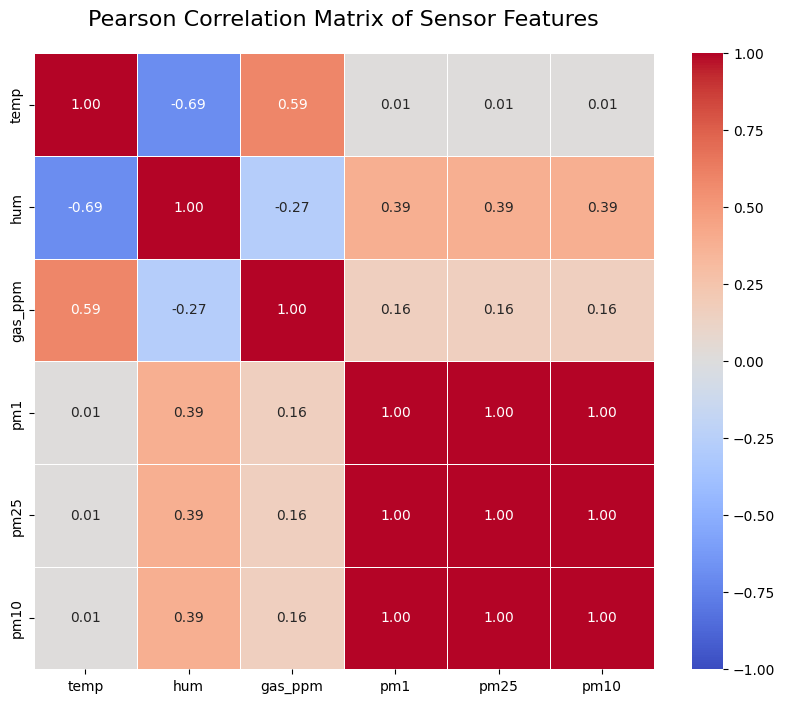

In [49]:
kolum_sensor = ['temp', 'hum', 'gas_ppm', 'pm1', 'pm25', 'pm10']
df_korelasi = df[kolum_sensor]

matriks_korelasi = df_korelasi.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriks_korelasi, 
            annot=True,        # Tunjuk nombor dalam kotak
            cmap='coolwarm',   # Warna biru (sejuk/negatif) ke merah (panas/positif)
            fmt=".2f",         # Format 2 titik perpuluhan
            linewidths=0.5, 
            vmax=1, vmin=-1)   # Had nilai dari -1 hingga 1

plt.title('Pearson Correlation Matrix of Sensor Features', fontsize=16, pad=20)
plt.show()

In [50]:
df.to_csv('Clean_dataset_nibong_10062026.csv')